# Лабораторная работа 2
## Реализация многослойного перцептрона на NumPy

## 1. Постановка задачи

В этой работе реализован класс `MyMLP`, который обучает полносвязную нейронную сеть без готовых нейросетевых библиотек внутри класса. В `MyMLP` вручную написаны инициализация весов, прямой проход, функции активации, функции потерь, backpropagation, mini-batch gradient descent, предсказание и оценка качества.

Проверка проводится на двух задачах: Iris для многоклассовой классификации и Diabetes для регрессии. Дополнительно сравниваются четыре реализации: `MyMLP`, `sklearn`, `Keras / TensorFlow` и `PyTorch`.

## Проверка и установка библиотек

In [1]:
import sys
import subprocess
import importlib.util

packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "tensorflow": "tensorflow",
    "torch": "torch",
}

missing_packages = []

for module_name, package_name in packages.items():
    if importlib.util.find_spec(module_name) is None:
        missing_packages.append(package_name)

if missing_packages:
    print("Будут установлены пакеты:", missing_packages)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing_packages)
else:
    print("Все необходимые библиотеки уже установлены.")

Все необходимые библиотеки уже установлены.


## 2. Импорты и фиксация random seed

In [2]:
import time
import json
import random
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.datasets import load_iris, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.neural_network import MLPClassifier, MLPRegressor

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cwd = Path.cwd().resolve()
if (cwd / "lw" / "lw2").exists():
    LAB_DIR = cwd / "lw" / "lw2"
elif cwd.name == "lw2" and cwd.parent.name == "lw":
    LAB_DIR = cwd
else:
    raise RuntimeError("Запустите ноутбук из корня проекта или из папки lw/lw2")

OUTPUTS_DIR = LAB_DIR / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print("Device:", device)
print("Папка лабораторной работы:", LAB_DIR)

Device: cpu
Папка лабораторной работы: C:\itmo\Выпуклый анализ и глубокое обучение\lw\lw2


## 3. Теоретическая основа

Полносвязный слой вычисляет `Z = A @ W + b`, где `W` — веса, `b` — bias, а `A` — вход слоя. После этого применяется функция активации. Прямой проход получает предсказание, функция потерь измеряет ошибку, а обратное распространение ошибки вычисляет градиенты для всех слоёв.

В этой работе для классификации используется `softmax` и categorical cross entropy, для бинарной классификации поддержана binary cross entropy, а для регрессии используется MSE. Веса обновляются mini-batch gradient descent: данные перемешиваются, разбиваются на батчи, затем на каждом батче выполняются forward, loss, backward и шаг обновления.

## 4. Реализация класса MyMLP

In [3]:
class MyMLP:
    def __init__(
        self,
        layers_sizes,
        activations,
        task="multiclass_classification",
        learning_rate=0.01,
        regularization=None,
        l1_strength=0.0,
        l2_strength=0.0,
        random_state=42,
    ):
        self.layers_sizes = list(layers_sizes)
        self.activations = [activation.lower() for activation in activations]
        self.task = task
        self.learning_rate = learning_rate
        self.regularization = regularization
        self.l1_strength = l1_strength
        self.l2_strength = l2_strength
        self.rng = np.random.default_rng(random_state)
        self.weights = []
        self.biases = []
        self.history = {"loss": [], "val_loss": [], "metric": [], "val_metric": []}

        if len(self.layers_sizes) < 2:
            raise ValueError("В архитектуре должно быть минимум два слоя")
        if len(self.activations) != len(self.layers_sizes) - 1:
            raise ValueError("Для каждого слоя с весами нужна функция активации")
        if self.task not in {"multiclass_classification", "binary_classification", "regression"}:
            raise ValueError("Неизвестный тип задачи")
        if self.regularization not in {None, "l1", "l2", "l1l2"}:
            raise ValueError("Неизвестный тип регуляризации")

        self._initialize_weights()

    def _initialize_weights(self):
        self.weights = []
        self.biases = []
        for fan_in, fan_out, activation in zip(self.layers_sizes[:-1], self.layers_sizes[1:], self.activations):
            scale = np.sqrt(2.0 / fan_in) if activation == "relu" else np.sqrt(1.0 / fan_in)
            self.weights.append(self.rng.normal(0.0, scale, size=(fan_in, fan_out)))
            self.biases.append(np.zeros((1, fan_out)))

    @staticmethod
    def _activate(z, name):
        if name == "relu":
            return np.maximum(0.0, z)
        if name == "sigmoid":
            z = np.clip(z, -500.0, 500.0)
            return 1.0 / (1.0 + np.exp(-z))
        if name == "tanh":
            return np.tanh(z)
        if name == "linear":
            return z
        if name == "softmax":
            shifted = z - np.max(z, axis=1, keepdims=True)
            exp_values = np.exp(shifted)
            return exp_values / np.sum(exp_values, axis=1, keepdims=True)
        raise ValueError(f"Неизвестная функция активации: {name}")

    @staticmethod
    def _activation_derivative(z, activated, name):
        if name == "relu":
            return (z > 0.0).astype(float)
        if name == "sigmoid":
            return activated * (1.0 - activated)
        if name == "tanh":
            return 1.0 - activated ** 2
        if name == "linear":
            return np.ones_like(z)
        raise ValueError(f"Для активации {name} нет отдельной производной")

    def _forward(self, X):
        self._layer_inputs = [X]
        self._linear_outputs = []
        current = X
        for W, b, activation in zip(self.weights, self.biases, self.activations):
            z = current @ W + b
            current = self._activate(z, activation)
            self._linear_outputs.append(z)
            self._layer_inputs.append(current)
        return current

    def _regularization_loss(self):
        penalty = 0.0
        if self.regularization in {"l1", "l1l2"}:
            penalty += self.l1_strength * sum(np.sum(np.abs(W)) for W in self.weights)
        if self.regularization in {"l2", "l1l2"}:
            penalty += 0.5 * self.l2_strength * sum(np.sum(W ** 2) for W in self.weights)
        return penalty

    def _compute_loss(self, y_true, y_pred):
        eps = 1e-12
        if self.task == "multiclass_classification":
            clipped = np.clip(y_pred, eps, 1.0)
            data_loss = -np.mean(np.sum(y_true * np.log(clipped), axis=1))
        elif self.task == "binary_classification":
            clipped = np.clip(y_pred, eps, 1.0 - eps)
            data_loss = -np.mean(y_true * np.log(clipped) + (1.0 - y_true) * np.log(1.0 - clipped))
        else:
            data_loss = np.mean((y_pred - y_true) ** 2)
        return float(data_loss + self._regularization_loss())

    def _regularization_gradient(self, W):
        gradient = np.zeros_like(W)
        if self.regularization in {"l1", "l1l2"}:
            gradient += self.l1_strength * np.sign(W)
        if self.regularization in {"l2", "l1l2"}:
            gradient += self.l2_strength * W
        return gradient

    def _backward(self, y_true):
        y_pred = self._layer_inputs[-1]
        batch_size = y_true.shape[0]

        if self.task in {"multiclass_classification", "binary_classification"}:
            dZ = (y_pred - y_true) / batch_size
        else:
            dA = 2.0 * (y_pred - y_true) / batch_size
            dZ = dA * self._activation_derivative(self._linear_outputs[-1], self._layer_inputs[-1], self.activations[-1])

        gradients_W = [None] * len(self.weights)
        gradients_b = [None] * len(self.biases)

        for layer_index in range(len(self.weights) - 1, -1, -1):
            previous_activation = self._layer_inputs[layer_index]
            gradients_W[layer_index] = previous_activation.T @ dZ + self._regularization_gradient(self.weights[layer_index])
            gradients_b[layer_index] = np.sum(dZ, axis=0, keepdims=True)

            if layer_index > 0:
                dA = dZ @ self.weights[layer_index].T
                dZ = dA * self._activation_derivative(
                    self._linear_outputs[layer_index - 1],
                    self._layer_inputs[layer_index],
                    self.activations[layer_index - 1],
                )

        return gradients_W, gradients_b

    def _update_params(self, gradients_W, gradients_b):
        for layer_index in range(len(self.weights)):
            self.weights[layer_index] -= self.learning_rate * gradients_W[layer_index]
            self.biases[layer_index] -= self.learning_rate * gradients_b[layer_index]

    def fit(self, X, y, X_val=None, y_val=None, epochs=100, batch_size=32, verbose=0):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        if self.task in {"binary_classification", "regression"} and y.ndim == 1:
            y = y.reshape(-1, 1)
        if y_val is not None:
            y_val = np.asarray(y_val, dtype=float)
            if self.task in {"binary_classification", "regression"} and y_val.ndim == 1:
                y_val = y_val.reshape(-1, 1)

        self.history = {"loss": [], "val_loss": [], "metric": [], "val_metric": []}

        for epoch in range(epochs):
            indices = self.rng.permutation(len(X))
            for start in range(0, len(X), batch_size):
                batch_indices = indices[start : start + batch_size]
                X_batch = X[batch_indices]
                y_batch = y[batch_indices]
                self._forward(X_batch)
                gradients_W, gradients_b = self._backward(y_batch)
                self._update_params(gradients_W, gradients_b)

            train_pred = self._forward(X)
            self.history["loss"].append(self._compute_loss(y, train_pred))
            self.history["metric"].append(self.score(X, y))

            if X_val is not None and y_val is not None:
                val_pred = self._forward(X_val)
                self.history["val_loss"].append(self._compute_loss(y_val, val_pred))
                self.history["val_metric"].append(self.score(X_val, y_val))

            if verbose and ((epoch + 1) % verbose == 0 or epoch == 0):
                message = f"Эпоха {epoch + 1:4d}/{epochs}: loss={self.history['loss'][-1]:.4f}, metric={self.history['metric'][-1]:.4f}"
                if self.history["val_loss"]:
                    message += f", val_loss={self.history['val_loss'][-1]:.4f}, val_metric={self.history['val_metric'][-1]:.4f}"
                print(message)
        return self

    def predict_proba(self, X):
        return self._forward(np.asarray(X, dtype=float))

    def predict(self, X):
        output = self.predict_proba(X)
        if self.task == "multiclass_classification":
            return np.argmax(output, axis=1)
        if self.task == "binary_classification":
            return (output.ravel() >= 0.5).astype(int)
        return output.ravel()

    def score(self, X, y):
        y = np.asarray(y)
        prediction = self.predict(X)
        if self.task == "multiclass_classification":
            labels = np.argmax(y, axis=1) if y.ndim == 2 else y
            return float(np.mean(prediction == labels))
        if self.task == "binary_classification":
            return float(np.mean(prediction == y.ravel()))
        y_true = y.ravel()
        ss_res = np.sum((y_true - prediction) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        return float(1.0 - ss_res / ss_tot) if ss_tot > 0 else 0.0

Класс `MyMLP` оставлен полностью самостоятельным: внутри него нет TensorFlow, Keras, PyTorch, sklearn, autograd или jax. Эти библиотеки используются только снаружи для сравнения и расчёта метрик.

## 5. Подготовка данных

In [4]:
X_iris, y_iris = load_iris(return_X_y=True)

X_iris_train_full, X_iris_test, y_iris_train_full, y_iris_test = train_test_split(
    X_iris,
    y_iris,
    test_size=0.2,
    random_state=SEED,
    stratify=y_iris,
)
X_iris_train, X_iris_val, y_iris_train, y_iris_val = train_test_split(
    X_iris_train_full,
    y_iris_train_full,
    test_size=0.2,
    random_state=SEED,
    stratify=y_iris_train_full,
)

iris_scaler = StandardScaler()
X_iris_train = iris_scaler.fit_transform(X_iris_train)
X_iris_val = iris_scaler.transform(X_iris_val)
X_iris_test = iris_scaler.transform(X_iris_test)

y_iris_train_onehot = np.eye(3)[y_iris_train]
y_iris_val_onehot = np.eye(3)[y_iris_val]

X_diabetes, y_diabetes = load_diabetes(return_X_y=True)

X_diabetes_train_full, X_diabetes_test, y_diabetes_train_full, y_diabetes_test = train_test_split(
    X_diabetes,
    y_diabetes,
    test_size=0.2,
    random_state=SEED,
)
X_diabetes_train, X_diabetes_val, y_diabetes_train, y_diabetes_val = train_test_split(
    X_diabetes_train_full,
    y_diabetes_train_full,
    test_size=0.2,
    random_state=SEED,
)

diabetes_scaler = StandardScaler()
X_diabetes_train = diabetes_scaler.fit_transform(X_diabetes_train)
X_diabetes_val = diabetes_scaler.transform(X_diabetes_val)
X_diabetes_test = diabetes_scaler.transform(X_diabetes_test)

y_scaler = StandardScaler()
y_diabetes_train_scaled = y_scaler.fit_transform(y_diabetes_train.reshape(-1, 1))
y_diabetes_val_scaled = y_scaler.transform(y_diabetes_val.reshape(-1, 1))

print("Iris train/val/test:", X_iris_train.shape, X_iris_val.shape, X_iris_test.shape)
print("Diabetes train/val/test:", X_diabetes_train.shape, X_diabetes_val.shape, X_diabetes_test.shape)

Iris train/val/test: (96, 4) (24, 4) (30, 4)
Diabetes train/val/test: (282, 10) (71, 10) (89, 10)


## 6. Эксперименты MyMLP

In [5]:
configs_classification = [
    {"name": "MyMLP clf 1", "layers_sizes": [4, 8, 3], "activations": ["relu", "softmax"], "learning_rate": 0.03, "epochs": 300, "batch_size": 16},
    {"name": "MyMLP clf 2", "layers_sizes": [4, 16, 8, 3], "activations": ["relu", "relu", "softmax"], "learning_rate": 0.03, "epochs": 400, "batch_size": 16},
    {"name": "MyMLP clf 3", "layers_sizes": [4, 32, 16, 3], "activations": ["tanh", "relu", "softmax"], "learning_rate": 0.01, "epochs": 500, "batch_size": 16},
]

configs_regression = [
    {"name": "MyMLP reg 1", "layers_sizes": [10, 32, 1], "activations": ["relu", "linear"], "learning_rate": 0.01, "epochs": 500, "batch_size": 32},
    {"name": "MyMLP reg 2", "layers_sizes": [10, 64, 32, 1], "activations": ["relu", "relu", "linear"], "learning_rate": 0.005, "epochs": 700, "batch_size": 32},
]

experiment_rows = []
classification_models = {}
regression_models = {}

for config in configs_classification:
    model = MyMLP(
        layers_sizes=config["layers_sizes"],
        activations=config["activations"],
        task="multiclass_classification",
        learning_rate=config["learning_rate"],
        random_state=SEED,
    )
    start = time.perf_counter()
    model.fit(X_iris_train, y_iris_train_onehot, X_val=X_iris_val, y_val=y_iris_val_onehot, epochs=config["epochs"], batch_size=config["batch_size"])
    train_time = time.perf_counter() - start
    start = time.perf_counter()
    y_pred = model.predict(X_iris_test)
    inference_time = time.perf_counter() - start
    accuracy = accuracy_score(y_iris_test, y_pred)
    f1 = f1_score(y_iris_test, y_pred, average="macro")
    classification_models[config["name"]] = model
    experiment_rows.append(
        {
            "Задача": "Классификация Iris",
            "Модель": config["name"],
            "Архитектура": str(config["layers_sizes"]),
            "Активации": ", ".join(config["activations"]),
            "Learning rate": config["learning_rate"],
            "Batch size": config["batch_size"],
            "Epochs": config["epochs"],
            "Train time, sec": train_time,
            "Inference time, sec": inference_time,
            "Accuracy": accuracy,
            "F1 macro": f1,
            "MSE": "-",
            "RMSE": "-",
            "MAE": "-",
            "R2": "-",
            "Комментарий": "Собственная реализация на NumPy",
        }
    )

for config in configs_regression:
    model = MyMLP(
        layers_sizes=config["layers_sizes"],
        activations=config["activations"],
        task="regression",
        learning_rate=config["learning_rate"],
        random_state=SEED,
    )
    start = time.perf_counter()
    model.fit(X_diabetes_train, y_diabetes_train_scaled, X_val=X_diabetes_val, y_val=y_diabetes_val_scaled, epochs=config["epochs"], batch_size=config["batch_size"])
    train_time = time.perf_counter() - start
    start = time.perf_counter()
    y_pred_scaled = model.predict(X_diabetes_test)
    inference_time = time.perf_counter() - start
    y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    mse = mean_squared_error(y_diabetes_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_diabetes_test, y_pred)
    r2 = r2_score(y_diabetes_test, y_pred)
    regression_models[config["name"]] = model
    experiment_rows.append(
        {
            "Задача": "Регрессия Diabetes",
            "Модель": config["name"],
            "Архитектура": str(config["layers_sizes"]),
            "Активации": ", ".join(config["activations"]),
            "Learning rate": config["learning_rate"],
            "Batch size": config["batch_size"],
            "Epochs": config["epochs"],
            "Train time, sec": train_time,
            "Inference time, sec": inference_time,
            "Accuracy": "-",
            "F1 macro": "-",
            "MSE": mse,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2,
            "Комментарий": "Собственная реализация на NumPy",
        }
    )

experiments_df = pd.DataFrame(experiment_rows)
experiments_df.to_csv(OUTPUTS_DIR / "mympl_experiments.csv", index=False, encoding="utf-8-sig")
best_clf_row = max((row for row in experiment_rows if row["Задача"] == "Классификация Iris"), key=lambda row: row["Accuracy"])
best_reg_row = max((row for row in experiment_rows if row["Задача"] == "Регрессия Diabetes"), key=lambda row: row["R2"])
best_clf_model = classification_models[best_clf_row["Модель"]]
best_reg_model = regression_models[best_reg_row["Модель"]]
display(experiments_df.round(4))

,Задача,Модель,Архитектура,Активации,Learning rate,Batch size,Epochs,"Train time, sec","Inference time, sec",Accuracy,F1 macro,MSE,RMSE,MAE,R2,Комментарий
0,Классификация Iris,MyMLP clf 1,"[4, 8, 3]","relu, softmax",0.030,16,300,0.1588,0.0,0.966667,0.966583,-,-,-,-,Собственная реализация на NumPy
1,Классификация Iris,MyMLP clf 2,"[4, 16, 8, 3]","relu, relu, softmax",0.030,16,400,0.3762,0.0,0.933333,0.933333,-,-,-,-,Собственная реализация на NumPy
2,Классификация Iris,MyMLP clf 3,"[4, 32, 16, 3]","tanh, relu, softmax",0.010,16,500,0.5668,0.0,0.933333,0.933333,-,-,-,-,Собственная реализация на NumPy
3,Регрессия Diabetes,MyMLP reg 1,"[10, 32, 1]","relu, linear",0.010,32,500,0.3356,0.0,-,-,3030.031968,55.045726,41.681607,0.428096,Собственная реализация на NumPy
4,Регрессия Diabetes,MyMLP reg 2,"[10, 64, 32, 1]","relu, relu, linear",0.005,32,700,0.8573,0.0,-,-,4605.48998,67.86376,52.770085,0.130736,Собственная реализация на NumPy


## 7. Графики обучения лучших MyMLP

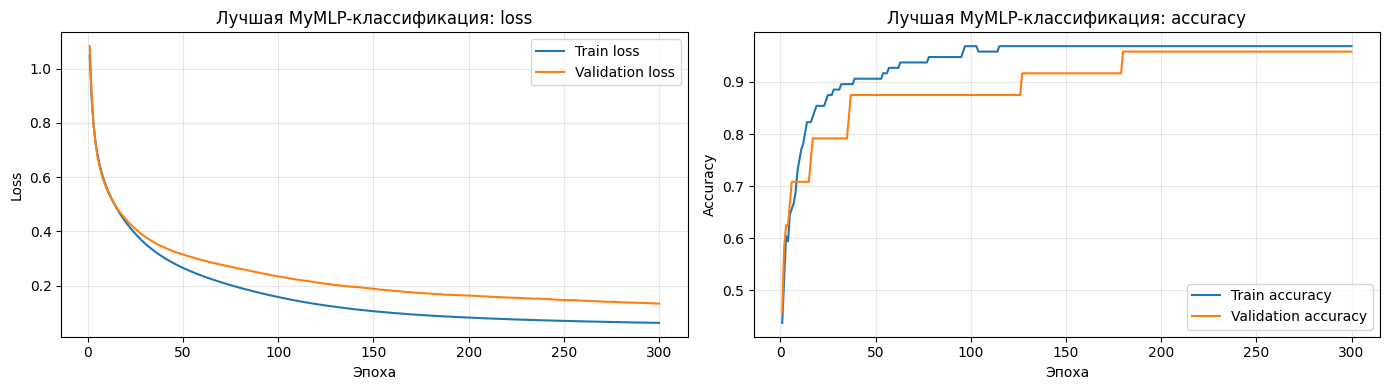

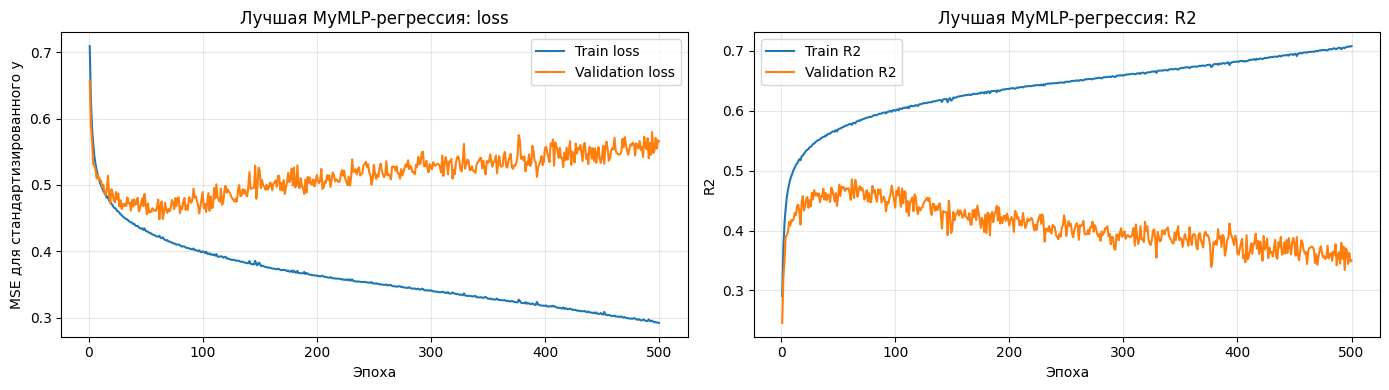

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
epochs = range(1, len(best_clf_model.history["loss"]) + 1)
axes[0].plot(epochs, best_clf_model.history["loss"], label="Train loss")
axes[0].plot(epochs, best_clf_model.history["val_loss"], label="Validation loss")
axes[0].set_title("Лучшая MyMLP-классификация: loss")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[1].plot(epochs, best_clf_model.history["metric"], label="Train accuracy")
axes[1].plot(epochs, best_clf_model.history["val_metric"], label="Validation accuracy")
axes[1].set_title("Лучшая MyMLP-классификация: accuracy")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "best_mympl_classification.png", dpi=140, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
epochs = range(1, len(best_reg_model.history["loss"]) + 1)
axes[0].plot(epochs, best_reg_model.history["loss"], label="Train loss")
axes[0].plot(epochs, best_reg_model.history["val_loss"], label="Validation loss")
axes[0].set_title("Лучшая MyMLP-регрессия: loss")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("MSE для стандартизированного y")
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[1].plot(epochs, best_reg_model.history["metric"], label="Train R2")
axes[1].plot(epochs, best_reg_model.history["val_metric"], label="Validation R2")
axes[1].set_title("Лучшая MyMLP-регрессия: R2")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("R2")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "best_mympl_regression.png", dpi=140, bbox_inches="tight")
plt.show()

## 8. Сравнение с sklearn, Keras / TensorFlow и PyTorch

In [7]:
comparison_rows = []

comparison_rows.append(
    {
        "Задача": "Классификация Iris",
        "Библиотека": "MyMLP",
        "Архитектура": best_clf_row["Архитектура"],
        "Train time, sec": best_clf_row["Train time, sec"],
        "Inference time, sec": best_clf_row["Inference time, sec"],
        "Основная метрика": best_clf_row["Accuracy"],
        "Дополнительные метрики": f"F1 macro = {best_clf_row['F1 macro']:.4f}",
        "Комментарий": best_clf_row["Модель"],
    }
)
comparison_rows.append(
    {
        "Задача": "Регрессия Diabetes",
        "Библиотека": "MyMLP",
        "Архитектура": best_reg_row["Архитектура"],
        "Train time, sec": best_reg_row["Train time, sec"],
        "Inference time, sec": best_reg_row["Inference time, sec"],
        "Основная метрика": best_reg_row["R2"],
        "Дополнительные метрики": f"RMSE = {best_reg_row['RMSE']:.4f}",
        "Комментарий": best_reg_row["Модель"],
    }
)

sklearn_clf = MLPClassifier(hidden_layer_sizes=(16, 8), activation="relu", solver="adam", max_iter=500, random_state=SEED)
start = time.perf_counter()
sklearn_clf.fit(X_iris_train, y_iris_train)
sklearn_clf_train_time = time.perf_counter() - start
start = time.perf_counter()
sklearn_clf_pred = sklearn_clf.predict(X_iris_test)
sklearn_clf_inference_time = time.perf_counter() - start
sklearn_clf_accuracy = accuracy_score(y_iris_test, sklearn_clf_pred)
sklearn_clf_f1 = f1_score(y_iris_test, sklearn_clf_pred, average="macro")
comparison_rows.append(
    {
        "Задача": "Классификация Iris",
        "Библиотека": "sklearn",
        "Архитектура": "[4, 16, 8, 3]",
        "Train time, sec": sklearn_clf_train_time,
        "Inference time, sec": sklearn_clf_inference_time,
        "Основная метрика": sklearn_clf_accuracy,
        "Дополнительные метрики": f"F1 macro = {sklearn_clf_f1:.4f}",
        "Комментарий": "MLPClassifier",
    }
)

sklearn_reg = MLPRegressor(hidden_layer_sizes=(64, 32), activation="relu", solver="adam", max_iter=700, random_state=SEED)
start = time.perf_counter()
sklearn_reg.fit(X_diabetes_train, y_diabetes_train)
sklearn_reg_train_time = time.perf_counter() - start
start = time.perf_counter()
sklearn_reg_pred = sklearn_reg.predict(X_diabetes_test)
sklearn_reg_inference_time = time.perf_counter() - start
sklearn_reg_mse = mean_squared_error(y_diabetes_test, sklearn_reg_pred)
sklearn_reg_rmse = np.sqrt(sklearn_reg_mse)
sklearn_reg_r2 = r2_score(y_diabetes_test, sklearn_reg_pred)
comparison_rows.append(
    {
        "Задача": "Регрессия Diabetes",
        "Библиотека": "sklearn",
        "Архитектура": "[10, 64, 32, 1]",
        "Train time, sec": sklearn_reg_train_time,
        "Inference time, sec": sklearn_reg_inference_time,
        "Основная метрика": sklearn_reg_r2,
        "Дополнительные метрики": f"RMSE = {sklearn_reg_rmse:.4f}",
        "Комментарий": "MLPRegressor",
    }
)

C:\Users\print\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


C:\Users\print\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (700) reached and the optimization hasn't converged yet.
  warnings.warn(


In [8]:
keras_clf = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(3, activation="softmax"),
])
keras_clf.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])
start = time.perf_counter()
keras_clf.fit(X_iris_train, y_iris_train_onehot, epochs=200, batch_size=16, verbose=0)
keras_clf_train_time = time.perf_counter() - start
start = time.perf_counter()
keras_clf_pred = np.argmax(keras_clf.predict(X_iris_test, verbose=0), axis=1)
keras_clf_inference_time = time.perf_counter() - start
keras_clf_accuracy = accuracy_score(y_iris_test, keras_clf_pred)
keras_clf_f1 = f1_score(y_iris_test, keras_clf_pred, average="macro")
comparison_rows.append(
    {
        "Задача": "Классификация Iris",
        "Библиотека": "Keras / TensorFlow",
        "Архитектура": "[4, 16, 8, 3]",
        "Train time, sec": keras_clf_train_time,
        "Inference time, sec": keras_clf_inference_time,
        "Основная метрика": keras_clf_accuracy,
        "Дополнительные метрики": f"F1 macro = {keras_clf_f1:.4f}",
        "Комментарий": "Sequential + Adam",
    }
)

keras_reg = keras.Sequential([
    layers.Input(shape=(10,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="linear"),
])
keras_reg.compile(optimizer=keras.optimizers.Adam(learning_rate=0.005), loss="mse")
start = time.perf_counter()
keras_reg.fit(X_diabetes_train, y_diabetes_train_scaled, epochs=300, batch_size=32, verbose=0)
keras_reg_train_time = time.perf_counter() - start
start = time.perf_counter()
keras_reg_pred_scaled = keras_reg.predict(X_diabetes_test, verbose=0).ravel()
keras_reg_inference_time = time.perf_counter() - start
keras_reg_pred = y_scaler.inverse_transform(keras_reg_pred_scaled.reshape(-1, 1)).ravel()
keras_reg_mse = mean_squared_error(y_diabetes_test, keras_reg_pred)
keras_reg_rmse = np.sqrt(keras_reg_mse)
keras_reg_r2 = r2_score(y_diabetes_test, keras_reg_pred)
comparison_rows.append(
    {
        "Задача": "Регрессия Diabetes",
        "Библиотека": "Keras / TensorFlow",
        "Архитектура": "[10, 64, 32, 1]",
        "Train time, sec": keras_reg_train_time,
        "Inference time, sec": keras_reg_inference_time,
        "Основная метрика": keras_reg_r2,
        "Дополнительные метрики": f"RMSE = {keras_reg_rmse:.4f}",
        "Комментарий": "Sequential + Adam",
    }
)

In [9]:
class TorchMLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_1, hidden_2, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_1),
            nn.ReLU(),
            nn.Linear(hidden_1, hidden_2),
            nn.ReLU(),
            nn.Linear(hidden_2, output_dim),
        )

    def forward(self, x):
        return self.net(x)


class TorchMLPRegressor(nn.Module):
    def __init__(self, input_dim, hidden_1, hidden_2, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_1),
            nn.ReLU(),
            nn.Linear(hidden_1, hidden_2),
            nn.ReLU(),
            nn.Linear(hidden_2, output_dim),
        )

    def forward(self, x):
        return self.net(x)


torch.manual_seed(SEED)
torch_clf = TorchMLPClassifier(4, 16, 8, 3).to(device)
torch_clf_criterion = nn.CrossEntropyLoss()
torch_clf_optimizer = optim.Adam(torch_clf.parameters(), lr=0.01)
X_iris_train_t = torch.tensor(X_iris_train, dtype=torch.float32, device=device)
y_iris_train_t = torch.tensor(y_iris_train, dtype=torch.long, device=device)
X_iris_test_t = torch.tensor(X_iris_test, dtype=torch.float32, device=device)

start = time.perf_counter()
for _ in range(200):
    torch_clf_optimizer.zero_grad()
    outputs = torch_clf(X_iris_train_t)
    loss = torch_clf_criterion(outputs, y_iris_train_t)
    loss.backward()
    torch_clf_optimizer.step()
torch_clf_train_time = time.perf_counter() - start

start = time.perf_counter()
with torch.no_grad():
    torch_clf_pred = torch.argmax(torch_clf(X_iris_test_t), dim=1).cpu().numpy()
torch_clf_inference_time = time.perf_counter() - start
torch_clf_accuracy = accuracy_score(y_iris_test, torch_clf_pred)
torch_clf_f1 = f1_score(y_iris_test, torch_clf_pred, average="macro")
comparison_rows.append(
    {
        "Задача": "Классификация Iris",
        "Библиотека": "PyTorch",
        "Архитектура": "[4, 16, 8, 3]",
        "Train time, sec": torch_clf_train_time,
        "Inference time, sec": torch_clf_inference_time,
        "Основная метрика": torch_clf_accuracy,
        "Дополнительные метрики": f"F1 macro = {torch_clf_f1:.4f}",
        "Комментарий": "nn.Linear + Adam",
    }
)

torch.manual_seed(SEED)
torch_reg = TorchMLPRegressor(10, 64, 32, 1).to(device)
torch_reg_criterion = nn.MSELoss()
torch_reg_optimizer = optim.Adam(torch_reg.parameters(), lr=0.005)
X_diabetes_train_t = torch.tensor(X_diabetes_train, dtype=torch.float32, device=device)
y_diabetes_train_t = torch.tensor(y_diabetes_train_scaled, dtype=torch.float32, device=device)
X_diabetes_test_t = torch.tensor(X_diabetes_test, dtype=torch.float32, device=device)

start = time.perf_counter()
for _ in range(50):
    torch_reg_optimizer.zero_grad()
    outputs = torch_reg(X_diabetes_train_t)
    loss = torch_reg_criterion(outputs, y_diabetes_train_t)
    loss.backward()
    torch_reg_optimizer.step()
torch_reg_train_time = time.perf_counter() - start

start = time.perf_counter()
with torch.no_grad():
    torch_reg_pred_scaled = torch_reg(X_diabetes_test_t).cpu().numpy().ravel()
torch_reg_inference_time = time.perf_counter() - start
torch_reg_pred = y_scaler.inverse_transform(torch_reg_pred_scaled.reshape(-1, 1)).ravel()
torch_reg_mse = mean_squared_error(y_diabetes_test, torch_reg_pred)
torch_reg_rmse = np.sqrt(torch_reg_mse)
torch_reg_mae = mean_absolute_error(y_diabetes_test, torch_reg_pred)
torch_reg_r2 = r2_score(y_diabetes_test, torch_reg_pred)
comparison_rows.append(
    {
        "Задача": "Регрессия Diabetes",
        "Библиотека": "PyTorch",
        "Архитектура": "[10, 64, 32, 1]",
        "Train time, sec": torch_reg_train_time,
        "Inference time, sec": torch_reg_inference_time,
        "Основная метрика": torch_reg_r2,
        "Дополнительные метрики": f"RMSE = {torch_reg_rmse:.4f}",
        "Комментарий": "nn.Linear + Adam",
    }
)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(OUTPUTS_DIR / "library_comparison.csv", index=False, encoding="utf-8-sig")
display(comparison_df.round(4))

,Задача,Библиотека,Архитектура,"Train time, sec","Inference time, sec",Основная метрика,Дополнительные метрики,Комментарий
0,Классификация Iris,MyMLP,"[4, 8, 3]",0.1588,0.0000,0.9667,F1 macro = 0.9666,MyMLP clf 1
1,Регрессия Diabetes,MyMLP,"[10, 32, 1]",0.3356,0.0000,0.4281,RMSE = 55.0457,MyMLP reg 1
2,Классификация Iris,sklearn,"[4, 16, 8, 3]",0.1232,0.0002,0.9667,F1 macro = 0.9666,MLPClassifier
3,Регрессия Diabetes,sklearn,"[10, 64, 32, 1]",0.5041,0.0005,0.4897,RMSE = 51.9973,MLPRegressor
4,Классификация Iris,Keras / TensorFlow,"[4, 16, 8, 3]",7.6637,0.0760,0.9333,F1 macro = 0.9333,Sequential + Adam
5,Регрессия Diabetes,Keras / TensorFlow,"[10, 64, 32, 1]",12.5848,0.0944,0.1324,RMSE = 67.8007,Sequential + Adam
6,Классификация Iris,PyTorch,"[4, 16, 8, 3]",0.1682,0.0003,0.9333,F1 macro = 0.9327,nn.Linear + Adam
7,Регрессия Diabetes,PyTorch,"[10, 64, 32, 1]",0.0460,0.0002,0.5127,RMSE = 50.8107,nn.Linear + Adam


## 9. Итоговые таблицы и графики сравнения

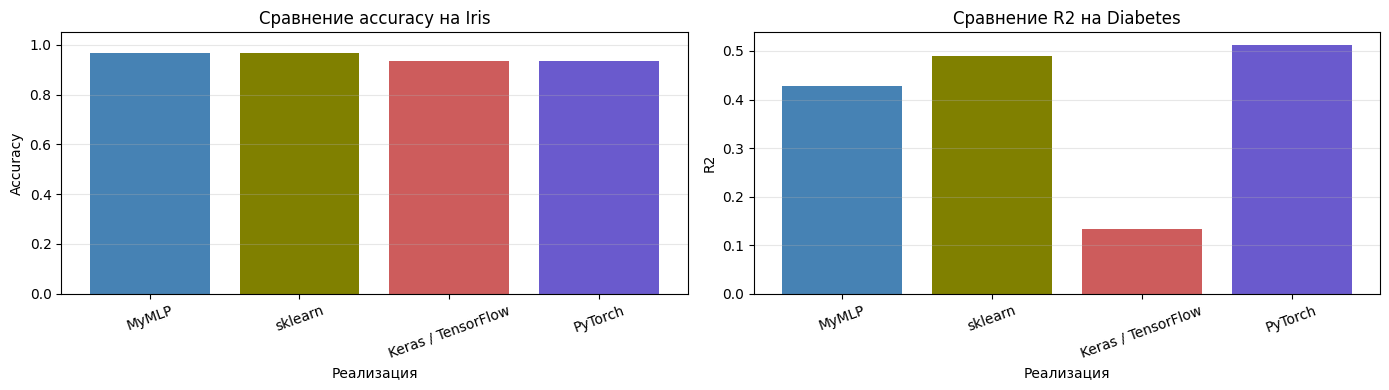

,Задача,Модель,Архитектура,Активации,Learning rate,Batch size,Epochs,"Train time, sec","Inference time, sec",Accuracy,F1 macro,MSE,RMSE,MAE,R2,Комментарий
0,Классификация Iris,MyMLP clf 1,"[4, 8, 3]","relu, softmax",0.030,16,300,0.1588,0.0,0.966667,0.966583,-,-,-,-,Собственная реализация на NumPy
1,Классификация Iris,MyMLP clf 2,"[4, 16, 8, 3]","relu, relu, softmax",0.030,16,400,0.3762,0.0,0.933333,0.933333,-,-,-,-,Собственная реализация на NumPy
2,Классификация Iris,MyMLP clf 3,"[4, 32, 16, 3]","tanh, relu, softmax",0.010,16,500,0.5668,0.0,0.933333,0.933333,-,-,-,-,Собственная реализация на NumPy
3,Регрессия Diabetes,MyMLP reg 1,"[10, 32, 1]","relu, linear",0.010,32,500,0.3356,0.0,-,-,3030.031968,55.045726,41.681607,0.428096,Собственная реализация на NumPy
4,Регрессия Diabetes,MyMLP reg 2,"[10, 64, 32, 1]","relu, relu, linear",0.005,32,700,0.8573,0.0,-,-,4605.48998,67.86376,52.770085,0.130736,Собственная реализация на NumPy


,Задача,Библиотека,Архитектура,"Train time, sec","Inference time, sec",Основная метрика,Дополнительные метрики,Комментарий
0,Классификация Iris,MyMLP,"[4, 8, 3]",0.1588,0.0000,0.9667,F1 macro = 0.9666,MyMLP clf 1
1,Регрессия Diabetes,MyMLP,"[10, 32, 1]",0.3356,0.0000,0.4281,RMSE = 55.0457,MyMLP reg 1
2,Классификация Iris,sklearn,"[4, 16, 8, 3]",0.1232,0.0002,0.9667,F1 macro = 0.9666,MLPClassifier
3,Регрессия Diabetes,sklearn,"[10, 64, 32, 1]",0.5041,0.0005,0.4897,RMSE = 51.9973,MLPRegressor
4,Классификация Iris,Keras / TensorFlow,"[4, 16, 8, 3]",7.6637,0.0760,0.9333,F1 macro = 0.9333,Sequential + Adam
5,Регрессия Diabetes,Keras / TensorFlow,"[10, 64, 32, 1]",12.5848,0.0944,0.1324,RMSE = 67.8007,Sequential + Adam
6,Классификация Iris,PyTorch,"[4, 16, 8, 3]",0.1682,0.0003,0.9333,F1 macro = 0.9327,nn.Linear + Adam
7,Регрессия Diabetes,PyTorch,"[10, 64, 32, 1]",0.0460,0.0002,0.5127,RMSE = 50.8107,nn.Linear + Adam


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

classification_comparison = comparison_df[comparison_df["Задача"] == "Классификация Iris"].copy()
regression_comparison = comparison_df[comparison_df["Задача"] == "Регрессия Diabetes"].copy()

axes[0].bar(classification_comparison["Библиотека"], classification_comparison["Основная метрика"].astype(float), color=["steelblue", "olive", "indianred", "slateblue"])
axes[0].set_title("Сравнение accuracy на Iris")
axes[0].set_xlabel("Реализация")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.0, 1.05)
axes[0].grid(axis="y", alpha=0.3)
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(regression_comparison["Библиотека"], regression_comparison["Основная метрика"].astype(float), color=["steelblue", "olive", "indianred", "slateblue"])
axes[1].set_title("Сравнение R2 на Diabetes")
axes[1].set_xlabel("Реализация")
axes[1].set_ylabel("R2")
axes[1].grid(axis="y", alpha=0.3)
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "library_comparison.png", dpi=140, bbox_inches="tight")
plt.show()

display(experiments_df.round(4))
display(comparison_df.round(4))

In [11]:
summary = {
    "mympl_experiments_count": len(experiments_df),
    "best_classification": {
        "model": best_clf_row["Модель"],
        "architecture": best_clf_row["Архитектура"],
        "accuracy": float(best_clf_row["Accuracy"]),
        "f1_macro": float(best_clf_row["F1 macro"]),
    },
    "best_regression": {
        "model": best_reg_row["Модель"],
        "architecture": best_reg_row["Архитектура"],
        "r2": float(best_reg_row["R2"]),
        "rmse": float(best_reg_row["RMSE"]),
    },
    "sklearn": {
        "classification_accuracy": float(sklearn_clf_accuracy),
        "classification_f1_macro": float(sklearn_clf_f1),
        "regression_r2": float(sklearn_reg_r2),
        "regression_rmse": float(sklearn_reg_rmse),
    },
    "keras": {
        "classification_accuracy": float(keras_clf_accuracy),
        "classification_f1_macro": float(keras_clf_f1),
        "regression_r2": float(keras_reg_r2),
        "regression_rmse": float(keras_reg_rmse),
    },
    "pytorch": {
        "classification_accuracy": float(torch_clf_accuracy),
        "classification_f1_macro": float(torch_clf_f1),
        "regression_r2": float(torch_reg_r2),
        "regression_rmse": float(torch_reg_rmse),
    },
}

with (OUTPUTS_DIR / "lab2_summary.json").open("w", encoding="utf-8") as file:
    json.dump(summary, file, ensure_ascii=False, indent=2)

print("Результаты сохранены в:", OUTPUTS_DIR)

Результаты сохранены в: C:\itmo\Выпуклый анализ и глубокое обучение\lw\lw2\outputs


## Итоговые выводы

В лабораторной работе реализован класс `MyMLP` на NumPy без использования TensorFlow, Keras, PyTorch, sklearn, autograd или jax внутри класса. Проверены 5 конфигураций `MyMLP`: 3 для классификации Iris и 2 для регрессии Diabetes.

Лучший результат `MyMLP` на Iris показала конфигурация `MyMLP clf 1` с архитектурой `[4, 8, 3]`: accuracy = 0.9667, F1 macro = 0.9666. Этот результат совпал с `sklearn` по accuracy и F1 macro.

Для регрессии Diabetes лучшей среди `MyMLP` стала конфигурация `MyMLP reg 1` с архитектурой `[10, 32, 1]`: R2 = 0.4281, RMSE = 55.0457. На этой задаче `MyMLP` уступил `sklearn` по R2 (0.4897) и RMSE (51.9973), но показал рабочее качество собственной реализации обратного распространения ошибки.

Сравнение библиотек выполнено для обеих задач. На Iris получены accuracy: `MyMLP` = 0.9667, `sklearn` = 0.9667, `Keras / TensorFlow` = 0.9333, `PyTorch` = 0.9333. Для Diabetes получены R2: `MyMLP` = 0.4281, `sklearn` = 0.4897, `Keras / TensorFlow` = 0.1324, `PyTorch` = 0.5127.

Итоговые таблицы сохранены в `outputs/mympl_experiments.csv` и `outputs/library_comparison.csv`, сводка сохранена в `outputs/lab2_summary.json`, графики сохранены в папке `outputs`.
